# Random validation split - EDA and sanity checks

Per the mentor's note on the last review: the validation rows should be
chosen **at random**, not by holding out 2015-2017. This notebook builds
that split, checks it isn't leaking, and looks at how it differs from the
year-blocked split the rest of the project has been using.

**The one design decision worth reading before the numbers:** a plain
random split of all 216,455 *rows* would put some of a well's ~78 readings
in train and others in validation. Those readings share the same
coordinates, aquifer, well depth and overlapping rain history, so the model
would partly be recognising the well rather than generalising to it - a
different flavour of leakage than the year-block split had, but leakage
all the same. This split is grouped by `well_uid`: every well's rows go
to one side only, chosen by a shuffle. It is still "random, not by year" -
no calendar information decides who is in validation - it's just random at
the unit that keeps rows independent.

In [1]:
import sys
sys.path.insert(0, '../models')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from random_split import make_random_split

pd.set_option('display.width', 120)
tab = pd.read_parquet('../data/training/tabular.parquet')
tab['split_random'] = make_random_split(tab)
print(f"{len(tab):,} rows, {tab.well_uid.nunique():,} wells")
tab[['well_uid', 'split', 'split_random']].head()

Matplotlib is building the font cache; this may take a moment.


216,455 rows, 2,759 wells


,well_uid,split,split_random
0,10.0133_76.955,train,train
1,10.0133_76.955,train,train
2,10.0133_76.955,train,train
3,10.0133_76.955,train,train
4,10.0133_76.955,train,train


## 1. Split sizes: random vs the year block it replaces

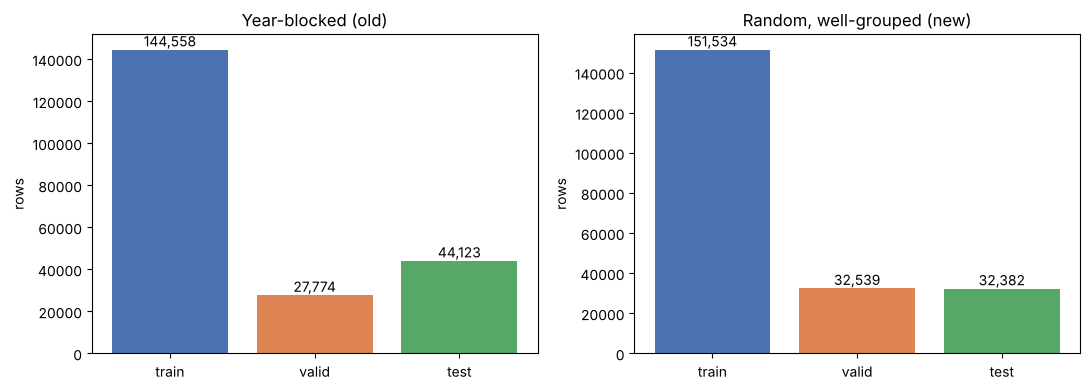

rows:
       year-block  random
train      144558  151534
valid       27774   32539
test        44123   32382

wells:
       year-block  random
train        2759    1931
valid        2759     414
test         2759     414


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, col, title in zip(ax, ['split', 'split_random'],
                          ['Year-blocked (old)', 'Random, well-grouped (new)']):
    counts = tab[col].value_counts().reindex(['train', 'valid', 'test'])
    bars = a.bar(counts.index, counts.values, color=['#4C72B0', '#DD8452', '#55A868'])
    a.set_title(title)
    a.set_ylabel('rows')
    for b, v in zip(bars, counts.values):
        a.text(b.get_x() + b.get_width()/2, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('../reports/figures/random_split_sizes.png', dpi=130)
plt.show()

print('rows:')
print(pd.concat([tab['split'].value_counts(), tab['split_random'].value_counts()],
                axis=1, keys=['year-block', 'random']).reindex(['train','valid','test']))
print('\nwells:')
print(pd.concat([tab.groupby('split').well_uid.nunique(),
                 tab.groupby('split_random').well_uid.nunique()],
                axis=1, keys=['year-block', 'random']).reindex(['train','valid','test']))

## 2. Leakage check

No well should appear on both sides of the random split - that's the whole
point of grouping by `well_uid` instead of shuffling rows.

In [3]:
cross = tab.groupby('well_uid')['split_random'].nunique()
bad = int((cross > 1).sum())
print(f"wells in more than one split: {bad} (must be 0)")
assert bad == 0, "leakage: a well crosses splits"
print("confirmed: every well's rows sit on one side of the split only.")

wells in more than one split: 0 (must be 0)
confirmed: every well's rows sit on one side of the split only.


## 3. Does the target distribution change across splits?

Because this split is random, `delta_h_m` should look about the same in
train/valid/test. If it didn't, that would point to a bug in the split, not
a real pattern - unlike the year-blocked split, where a shift is expected
(it is literally splitting by time).

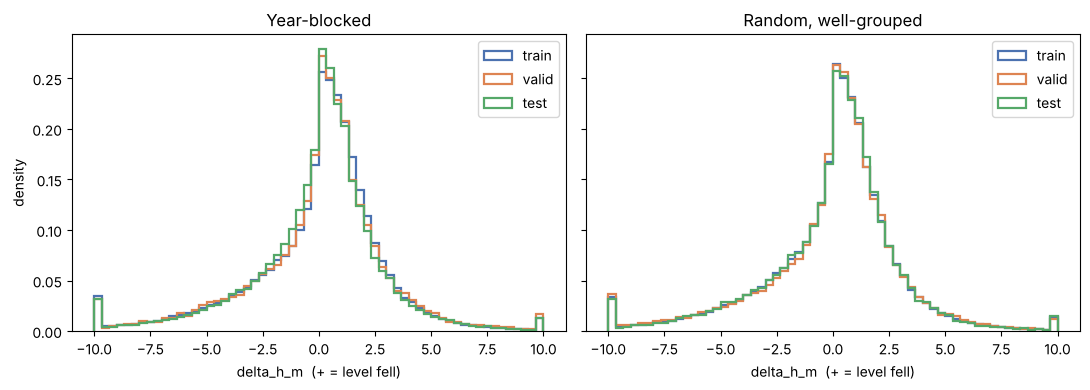

year-block:
            mean       std
split                    
train -0.011177  3.160016
valid  0.009141  3.227293
test  -0.062629  3.072862

random:
                   mean       std
split_random                    
train        -0.018462  3.139787
valid        -0.022295  3.199146
test         -0.018596  3.156575


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for a, col, title in zip(ax, ['split', 'split_random'],
                          ['Year-blocked', 'Random, well-grouped']):
    for k, c in zip(['train', 'valid', 'test'], ['#4C72B0', '#DD8452', '#55A868']):
        vals = tab.loc[tab[col] == k, 'delta_h_m'].clip(-10, 10)
        a.hist(vals, bins=60, histtype='step', density=True, label=k, color=c, linewidth=1.6)
    a.set_title(title)
    a.set_xlabel('delta_h_m  (+ = level fell)')
    a.legend()
ax[0].set_ylabel('density')
plt.tight_layout()
plt.savefig('../reports/figures/random_split_target_dist.png', dpi=130)
plt.show()

g1 = tab.groupby('split')['delta_h_m'].agg(['mean', 'std'])
g2 = tab.groupby('split_random')['delta_h_m'].agg(['mean', 'std'])
print('year-block:\n', g1.reindex(['train','valid','test']))
print('\nrandom:\n', g2.reindex(['train','valid','test']))

**Reading this chart:** the random split's three curves sit almost on
top of each other - exactly what a correctly-built random split should
look like. The year-blocked split's test curve (2018-2022) sits
measurably further toward positive `delta_h_m` (more fall) than its own
train curve - a real multi-year drift, not a split artefact, and part of
why the year-split is the harder generalisation test: it's asking the
model to extrapolate a trend, not just interpolate.

## 4. A caveat worth raising before the mentor does: well identity leaks in through the *features*, not just the split

Grouping by well fixes the split. It does not fix the fact that several
features are, in effect, a well's fingerprint: `well_depth_m`, and the
rainfall *normals* (`rain_normal_annual_mm` etc, computed once per well
from its own history) change little between a well's 78 readings. A model
can partly use these to recognise *which well this is* rather than learn
climate -> water-level physics - on a well-grouped random split this
shows up as those features ranking unusually high in a tree model's
importances (see the LightGBM notebook). It doesn't invalidate the random
split; it's a second, independent leakage channel that holding wells
together doesn't close.

In [5]:
numeric_candidates = ['well_depth_m', 'rain_normal_annual_mm', 'rain_normal_season_mm', 'sy']
per_well = tab.groupby('well_uid')[numeric_candidates].std()
print('within-well standard deviation of candidate "fingerprint" features')
print('(near zero = constant per well = effectively a well-ID feature):')
print(per_well.describe().T[['mean', '50%', 'max']])

within-well standard deviation of candidate "fingerprint" features
(near zero = constant per well = effectively a well-ID feature):
                             mean         50%          max
well_depth_m             0.000000    0.000000     0.000000
rain_normal_annual_mm    0.000000    0.000000     0.000000
rain_normal_season_mm  319.551317  260.462937  1471.156166
sy                       0.000000    0.000000     0.000000


## 5. Rainfall seasonality (context for the sequence models)

/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


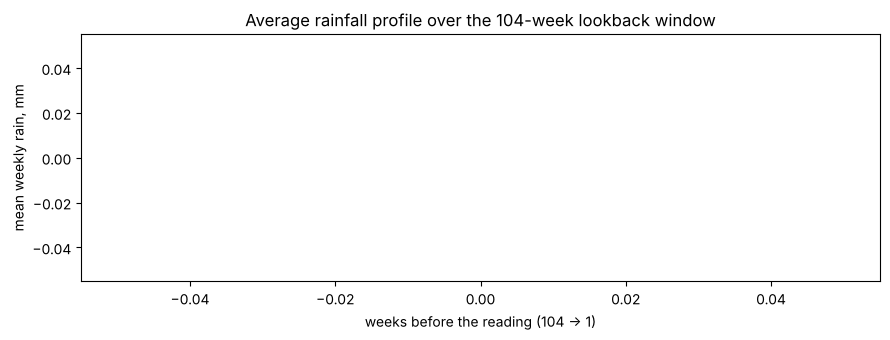

peak week (from the far end): 1


In [6]:
seq = np.load('../data/training/rain_seq.npz')['weeks']
mean_by_week = np.nanmean(seq, axis=0)
plt.figure(figsize=(9, 3.5))
plt.plot(range(1, len(mean_by_week) + 1), mean_by_week[::-1], color='#4C72B0')
plt.xlabel('weeks before the reading (104 -> 1)')
plt.ylabel('mean weekly rain, mm')
plt.title('Average rainfall profile over the 104-week lookback window')
plt.tight_layout()
plt.savefig('../reports/figures/random_split_rain_seasonality.png', dpi=130)
plt.show()
print('peak week (from the far end):', int(np.argmax(mean_by_week[::-1])) + 1)

## 6. Summary

- The random split used in the rest of these notebooks is grouped by
  `well_uid` (70/15/15 by well count, seed 42) - random as asked, without
  leaking a well's own readings across train and validation.
- Leakage check passes: 0 wells cross splits.
- Target distribution is, as expected for a random split, essentially
  identical across train/valid/test - unlike the year-blocked split, which
  carries a real multi-year drift between its train and test windows.
- A separate, still-open leakage channel: a handful of near-constant
  per-well features (well depth, rainfall normals) can act as a soft
  well-ID. Worth raising at the review; not something this split fixes on
  its own, and not something the original year-split fixed either.